# Credit Card Fraud Detection
Identify **fraudulent credit card transactions** using machine learning.

**Dataset Features:**
- `Time`, `Amount`, and anonymized features `V1` to `V28`
- `Class`: 1 = Fraud, 0 = Non-Fraud

## Step 1: Import Libraries

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)
from sklearn.utils import resample

import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


## Step 2: Load & Explore the Dataset

In [4]:
# Load the dataset
df = pd.read_csv(r"C:\Users\hp\Downloads\data_science project2\creditcard.csv")

print("Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nData Types:")
print(df.dtypes)
print("\nFirst 5 rows:")
df.head()

Shape: (284807, 31)

Column Names:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Data Types:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

First 5 rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())

print("\nBasic Statistics:")
df.describe()

Missing Values:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Basic Statistics:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


## Step 3: Exploratory Data Analysis (EDA)

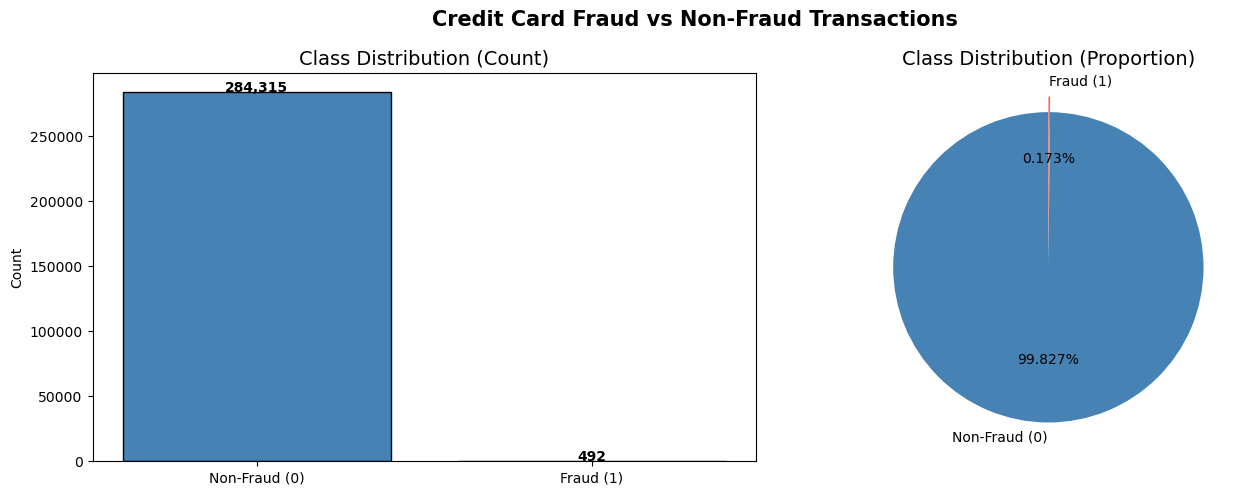


Total Transactions : 284,807
Non-Fraud (0)      : 284,315 (99.827%)
Fraud (1)          : 492 (0.173%)

⚠️  Dataset is highly imbalanced — fraud represents < 0.2% of all transactions!


In [6]:
# ── Class Distribution ──────────────────────────────────────────────────────
class_counts = df['Class'].value_counts()
class_labels = ['Non-Fraud (0)', 'Fraud (1)']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
axes[0].bar(class_labels, class_counts.values, color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Class Distribution (Count)', fontsize=14)
axes[0].set_ylabel('Count')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(class_counts.values, labels=class_labels,
            autopct='%1.3f%%', colors=['steelblue', 'tomato'],
            startangle=90, explode=(0, 0.1))
axes[1].set_title('Class Distribution (Proportion)', fontsize=14)

plt.suptitle('Credit Card Fraud vs Non-Fraud Transactions', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nTotal Transactions : {len(df):,}")
print(f"Non-Fraud (0)      : {class_counts[0]:,} ({class_counts[0]/len(df)*100:.3f}%)")
print(f"Fraud (1)          : {class_counts[1]:,} ({class_counts[1]/len(df)*100:.3f}%)")
print(f"\n⚠️  Dataset is highly imbalanced — fraud represents < 0.2% of all transactions!")

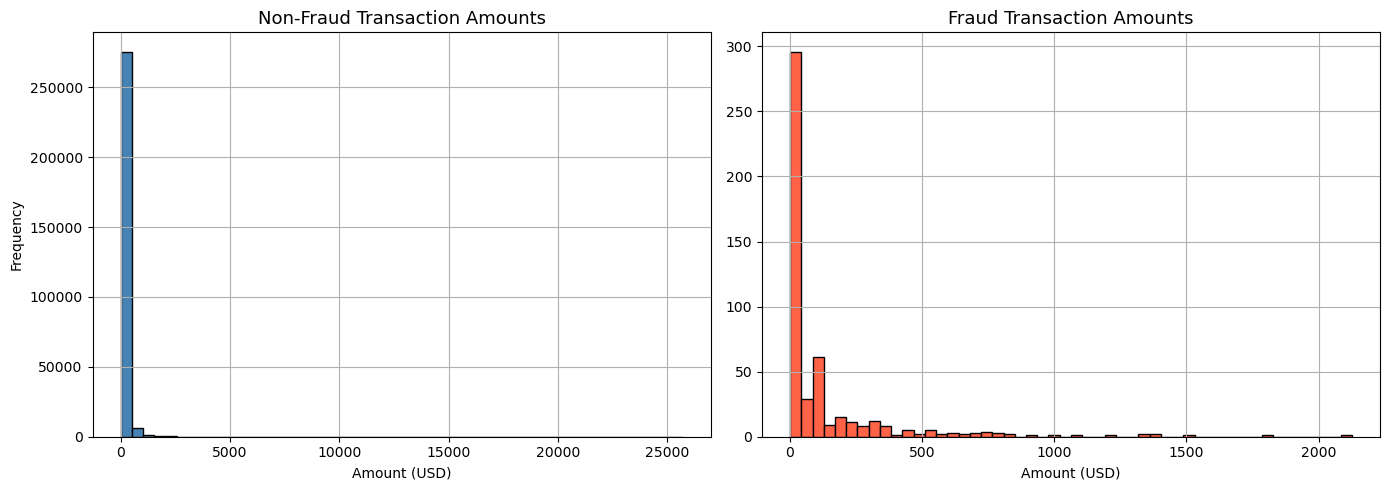

Fraud Amount Stats:
count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64


In [7]:
# ── Transaction Amount Distribution by Class ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df[df['Class'] == 0]['Amount'].hist(bins=50, ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Non-Fraud Transaction Amounts', fontsize=13)
axes[0].set_xlabel('Amount (USD)')
axes[0].set_ylabel('Frequency')

df[df['Class'] == 1]['Amount'].hist(bins=50, ax=axes[1], color='tomato', edgecolor='black')
axes[1].set_title('Fraud Transaction Amounts', fontsize=13)
axes[1].set_xlabel('Amount (USD)')

plt.tight_layout()
plt.show()

print("Fraud Amount Stats:")
print(df[df['Class']==1]['Amount'].describe())

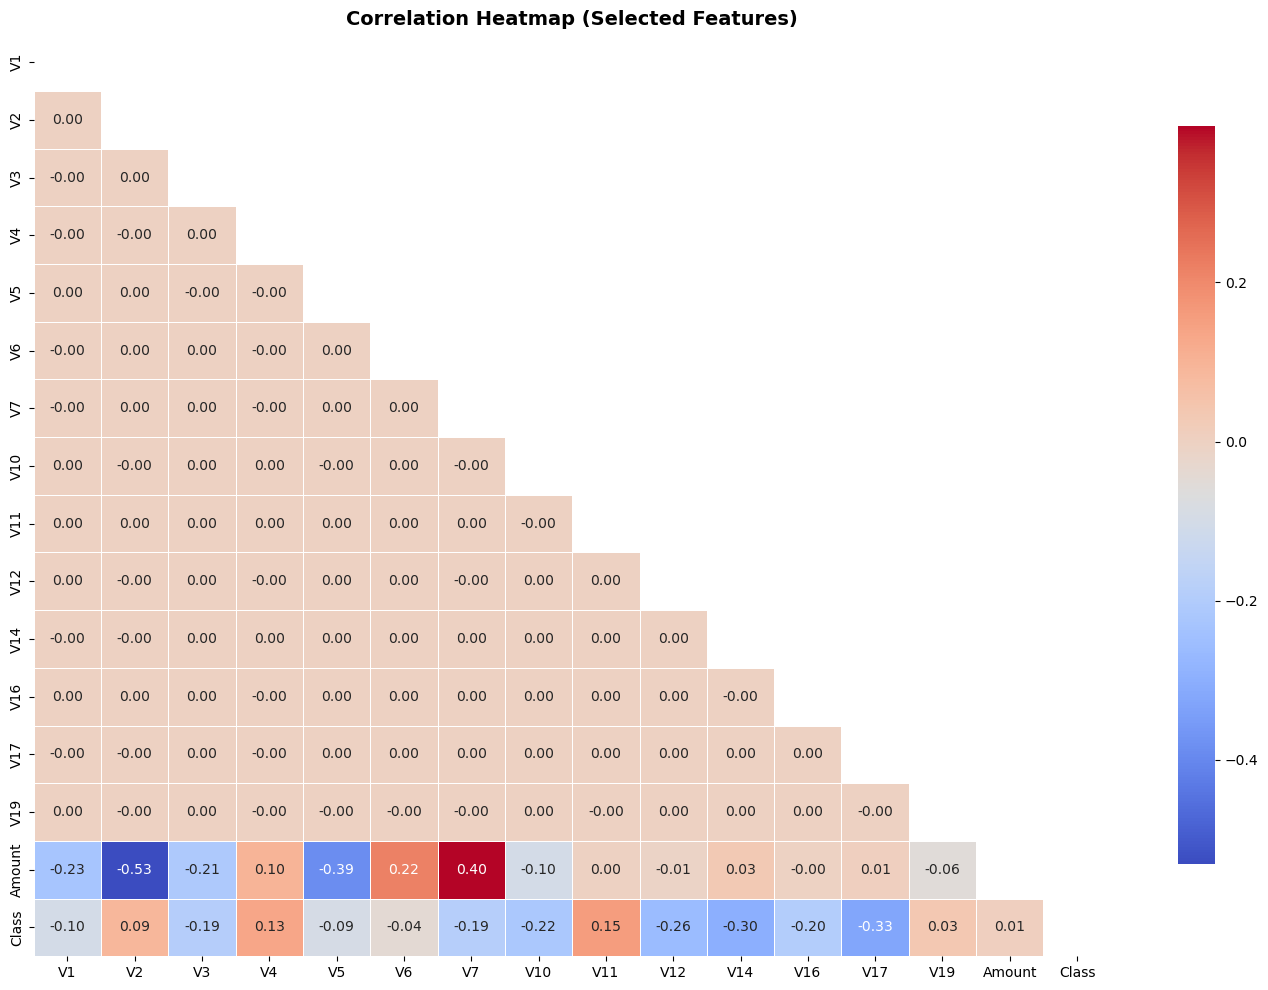

In [8]:
# ── Correlation Heatmap ───────────────────────────────────────────────────────
# Selecting a subset of features for readability
corr_cols = ['V1','V2','V3','V4','V5','V6','V7','V10','V11','V12',
             'V14','V16','V17','V19','Amount','Class']

plt.figure(figsize=(14, 10))
corr = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap (Selected Features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 4: Data Preprocessing

In [9]:
# ── Feature Scaling for 'Amount' and 'Time' ──────────────────────────────────
scaler = StandardScaler()

df['scaled_Amount'] = scaler.fit_transform(df[['Amount']])
df['scaled_Time']   = scaler.fit_transform(df[['Time']])

# Drop original unscaled columns
df.drop(columns=['Amount', 'Time'], inplace=True)

# Move Class column to the end for clarity
cols = [c for c in df.columns if c != 'Class'] + ['Class']
df = df[cols]

print("After scaling — shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

After scaling — shape: (284807, 31)
Columns: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'scaled_Amount', 'scaled_Time', 'Class']


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,scaled_Amount,scaled_Time,Class
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.244964,-1.996583,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.342475,-1.996583,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.160686,-1.996562,0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.140534,-1.996562,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,-0.073403,-1.996541,0


## Step 5: Handle Class Imbalance (Undersampling)

In [10]:
# ── Undersample the majority class for balanced training ─────────────────────
fraud     = df[df['Class'] == 1]
non_fraud = df[df['Class'] == 0]

print(f"Fraud samples     : {len(fraud):,}")
print(f"Non-Fraud samples : {len(non_fraud):,}")

# Undersample non-fraud to match fraud count
non_fraud_sampled = resample(
    non_fraud,
    replace=False,
    n_samples=len(fraud),
    random_state=42
)

balanced_df = pd.concat([fraud, non_fraud_sampled]).sample(frac=1, random_state=42)

print(f"\nBalanced dataset size : {len(balanced_df):,}")
print("Class distribution after balancing:")
print(balanced_df['Class'].value_counts())

Fraud samples     : 492
Non-Fraud samples : 284,315

Balanced dataset size : 984
Class distribution after balancing:
Class
0    492
1    492
Name: count, dtype: int64


## Step 6: Train-Test Split & Model Training

In [11]:
# ── Define Features and Target ───────────────────────────────────────────────
X = balanced_df.drop('Class', axis=1)
y = balanced_df['Class']

# Train-test split with stratification (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set   : {X_train.shape}")
print(f"Test set       : {X_test.shape}")

# ── Logistic Regression ───────────────────────────────────────────────────────
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)
lr_proba = lr_model.predict_proba(X_test)[:, 1]

print("\n✅ Logistic Regression trained!")

# ── Random Forest ─────────────────────────────────────────────────────────────
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

print("✅ Random Forest trained!")

Training set   : (787, 30)
Test set       : (197, 30)

✅ Logistic Regression trained!
✅ Random Forest trained!


## Step 7: Evaluation

In [12]:
# ── Classification Reports ────────────────────────────────────────────────────
print("="*55)
print("       LOGISTIC REGRESSION - Classification Report")
print("="*55)
print(classification_report(y_test, lr_preds, target_names=['Non-Fraud', 'Fraud']))
print(f"ROC-AUC Score : {roc_auc_score(y_test, lr_proba):.4f}")

print("\n" + "="*55)
print("         RANDOM FOREST - Classification Report")
print("="*55)
print(classification_report(y_test, rf_preds, target_names=['Non-Fraud', 'Fraud']))
print(f"ROC-AUC Score : {roc_auc_score(y_test, rf_proba):.4f}")

       LOGISTIC REGRESSION - Classification Report
              precision    recall  f1-score   support

   Non-Fraud       0.93      0.96      0.95        99
       Fraud       0.96      0.93      0.94        98

    accuracy                           0.94       197
   macro avg       0.94      0.94      0.94       197
weighted avg       0.94      0.94      0.94       197

ROC-AUC Score : 0.9836

         RANDOM FOREST - Classification Report
              precision    recall  f1-score   support

   Non-Fraud       0.92      0.96      0.94        99
       Fraud       0.96      0.92      0.94        98

    accuracy                           0.94       197
   macro avg       0.94      0.94      0.94       197
weighted avg       0.94      0.94      0.94       197

ROC-AUC Score : 0.9801


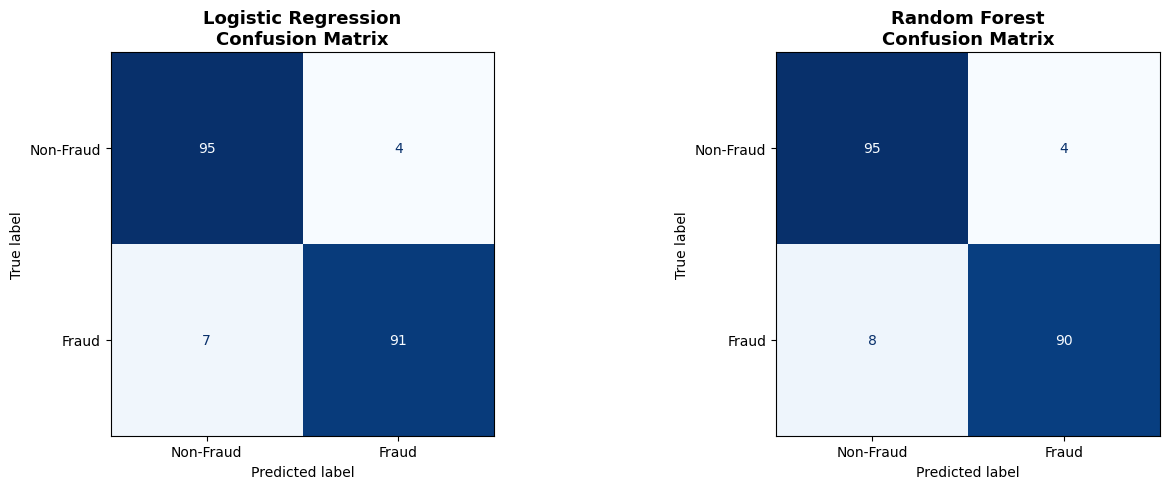

In [13]:
# ── Confusion Matrices ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, preds, title in zip(
    axes,
    [lr_preds, rf_preds],
    ['Logistic Regression', 'Random Forest']
):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Non-Fraud', 'Fraud'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{title}\nConfusion Matrix', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

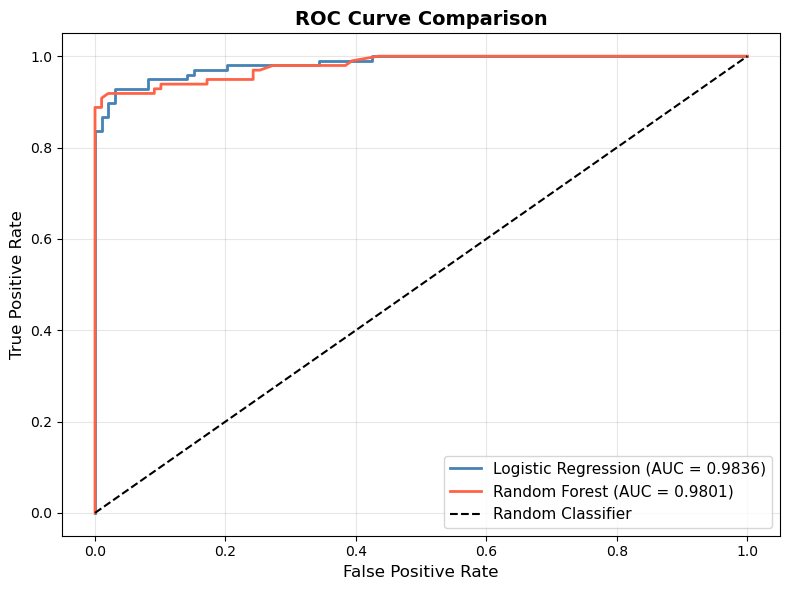

In [14]:
# ── ROC Curves ───────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 6))

for proba, name, color in [
    (lr_proba, 'Logistic Regression', 'steelblue'),
    (rf_proba, 'Random Forest',       'tomato')
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

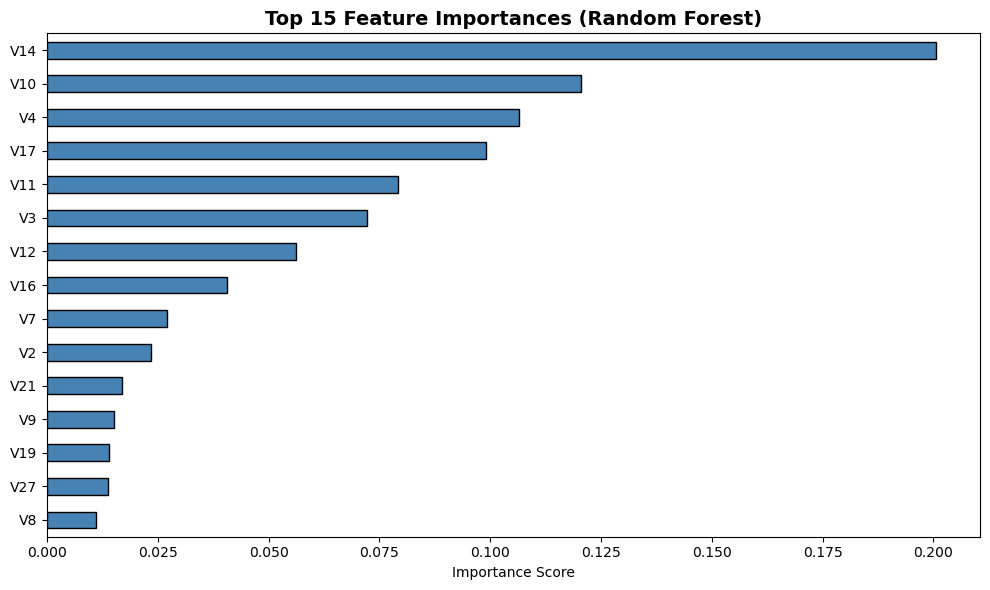

Top 5 most important features:
V14    0.200475
V10    0.120507
V4     0.106417
V17    0.098938
V11    0.079305
dtype: float64


In [15]:
# ── Feature Importance (Random Forest) ───────────────────────────────────────
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
top_features = importances.nlargest(15)

plt.figure(figsize=(10, 6))
top_features.sort_values().plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Top 15 Feature Importances (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("Top 5 most important features:")
print(top_features.head())

In [16]:
# ── Model Performance Summary Table ──────────────────────────────────────────
from sklearn.metrics import precision_score, recall_score, f1_score

summary = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy':  [accuracy_score(y_test, lr_preds),  accuracy_score(y_test, rf_preds)],
    'Precision': [precision_score(y_test, lr_preds), precision_score(y_test, rf_preds)],
    'Recall':    [recall_score(y_test, lr_preds),    recall_score(y_test, rf_preds)],
    'F1-Score':  [f1_score(y_test, lr_preds),        f1_score(y_test, rf_preds)],
    'ROC-AUC':   [roc_auc_score(y_test, lr_proba),   roc_auc_score(y_test, rf_proba)]
})
summary.set_index('Model', inplace=True)
summary = summary.round(4)

print("\n📊 Model Performance Summary:")
print(summary.to_string())
summary.style.highlight_max(axis=0, color='lightgreen')


📊 Model Performance Summary:
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                              
Logistic Regression    0.9442     0.9579  0.9286    0.9430   0.9836
Random Forest          0.9391     0.9574  0.9184    0.9375   0.9801


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.944200,0.957900,0.928600,0.943000,0.983600
Random Forest,0.939100,0.957400,0.918400,0.937500,0.980100


## Conclusion

| Aspect | Detail |
|---|---|
| **Problem** | Binary classification — Fraud vs Non-Fraud |
| **Imbalance Handling** | Undersampling the majority (non-fraud) class |
| **Preprocessing** | StandardScaler applied to `Time` and `Amount` |
| **Models Trained** | Logistic Regression & Random Forest |
| **Best Model** | Random Forest (higher F1 & ROC-AUC) |

### Future Work
- Try **SMOTE** (Synthetic Minority Oversampling) instead of undersampling
- Use **XGBoost / LightGBM** for better gradient boosting performance
- Apply **threshold tuning** to optimize recall for fraud detection
- Use **cross-validation** for more robust evaluation